<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=330127594" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [1]:
!pip install torchinfo
import torchinfo
import torch
import numpy as np

SEED=317
BATCH_SIZE = 128

In [2]:
from training import (
    save_checkpoint, 
    load_checkpoint, 
    train_model_stages,
    plot_learning_curves,
    mean_and_std_for_normalization
)

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze
)

In [3]:
from model import PseudoAlexNet, DEVICE

In [4]:
from natural_images import (
    load_dataset, 
    stratified_three_way_split,
    visualize_dataset_distribution,
    StochasticCutMixDataLoader
)

from screen_images import (
    CustomEnricoDataset,
    plot_image_list
)

## Preparation of the data Caltech101(natural images)

In [5]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.Resize((300,200)),
    v2.RGB(),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Normalize(mean=[np.float32(0.5462479), np.float32(0.52917147), np.float32(0.50259775)], std=[np.float32(0.30450362), np.float32(0.29856417), np.float32(0.30875134)], inplace=False)
])

transforms_augmented_list = [
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(300,200),
                         scale=(0.4,1.0))
        
    ]),
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(),
    ]),
    v2.RandomErasing(p=1)
]

nat_images = load_dataset(transforms_original=transforms, transforms_augmented_list=transforms_augmented_list)

100%|██████████| 137M/137M [00:04<00:00, 29.9MB/s]


In [6]:
nat_images_train, nat_images_val, nat_images_test = stratified_three_way_split(dataset=nat_images, train_ratio=0.7, 
                                                                             val_ratio=0.15, test_ratio=0.15, random_state=317)

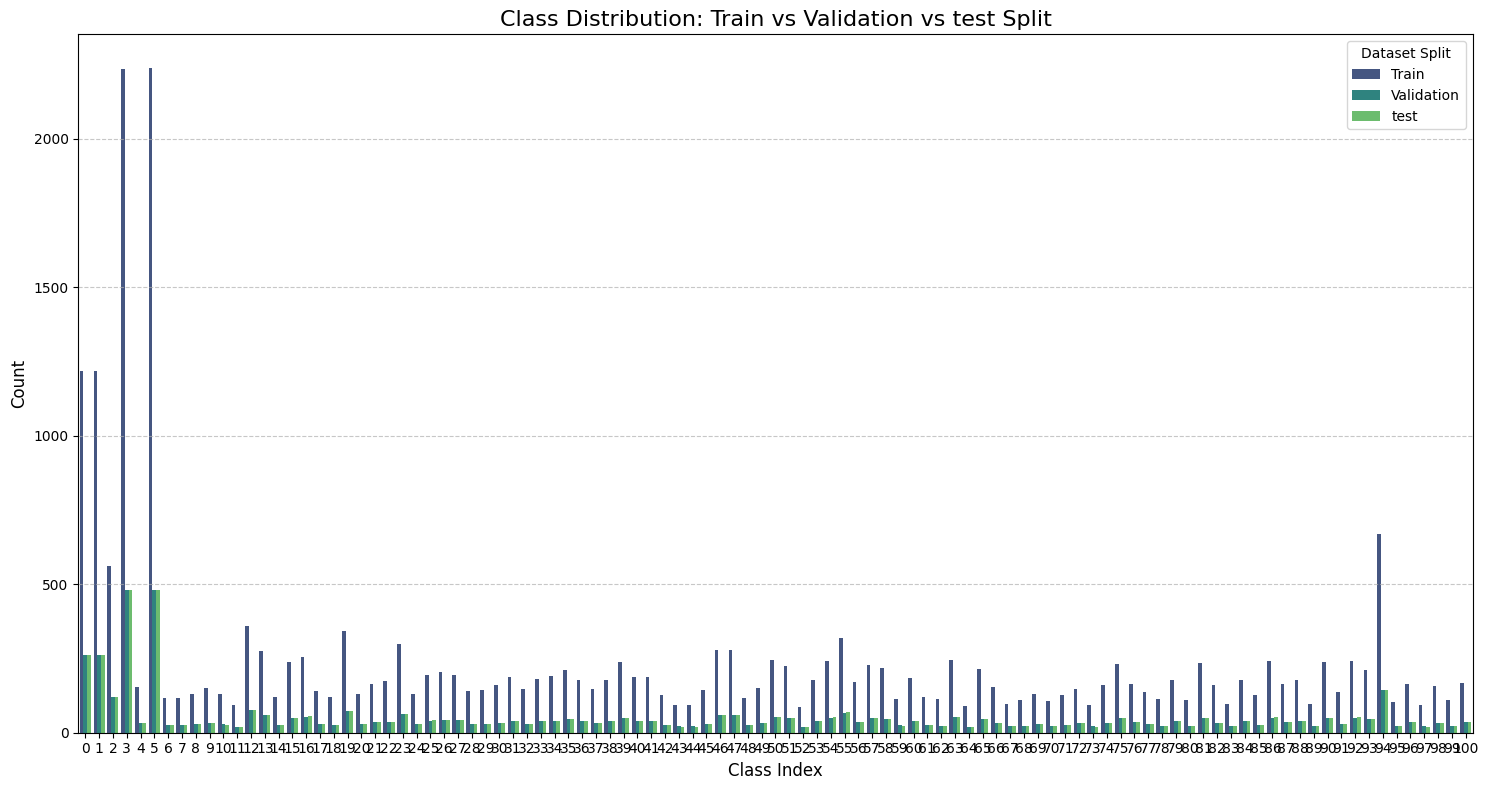

Total Training Samples:   24295 (70.0%)
Total Validation Samples: 5206 (15.0%)
Total test Samples:       5207 (15.0%)
Total Combined Samples:   34708


In [7]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [8]:
nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=3)
wrapped_nat_train_loader = StochasticCutMixDataLoader(
    nat_train_loader, num_classes=101, p=0.5
)

nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)

## Training the model on Caltech101

In [9]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 50

model = PseudoAlexNet(tiny_factor=3,p=0.25) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.NLLLoss()
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 3*1e-4, 'weight_decay': 1e-2},
    {'params': model.classifier.parameters(), 'lr': 3*1e-4, 'weight_decay': 1e-2}
], eps=1e-5)

val_loss_list_nat = []
train_loss_list_nat = []

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

In [10]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=wrapped_nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS,
                                                            stage_name="nat_images")

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

=== Training on the nat_images ===
Starting training of the nat_images in 50 epochs.
 nat_images training epoch 1/50...
Train Epoch: 1 [0/24320 (0%)]	Loss: 5.318089
Train Epoch: 1 [384/24320 (2%)]	Loss: 4.717682
Train Epoch: 1 [768/24320 (3%)]	Loss: 4.449587
Train Epoch: 1 [1152/24320 (5%)]	Loss: 4.545156
Train Epoch: 1 [1536/24320 (6%)]	Loss: 4.355449
Train Epoch: 1 [1920/24320 (8%)]	Loss: 3.899913
Train Epoch: 1 [2304/24320 (9%)]	Loss: 4.525703
Train Epoch: 1 [2688/24320 (11%)]	Loss: 4.376352
Train Epoch: 1 [3072/24320 (13%)]	Loss: 4.154205
Train Epoch: 1 [3456/24320 (14%)]	Loss: 4.182556
Train Epoch: 1 [3840/24320 (16%)]	Loss: 3.613627
Train Epoch: 1 [4224/24320 (17%)]	Loss: 3.947411
Train Epoch: 1 [4608/24320 (19%)]	Loss: 3.387725
Train Epoch: 1 [4992/24320 (21%)]	Loss: 3.696865
Train Epoch: 1 [5376/24320 (22%)]	Loss: 3.592444
Train Epoch: 1 [5760/24320 (24%)]	Loss: 4.239931
Train Epoch: 1 [6144/24320 (25%)]	Loss: 3.255817
Train Epoch: 1 [6528/24320 (27%)]	Loss: 3.242403
Train Epoc

(0.8322617440688901, 0.8081428845784521)

## Plotting training and validation test losses

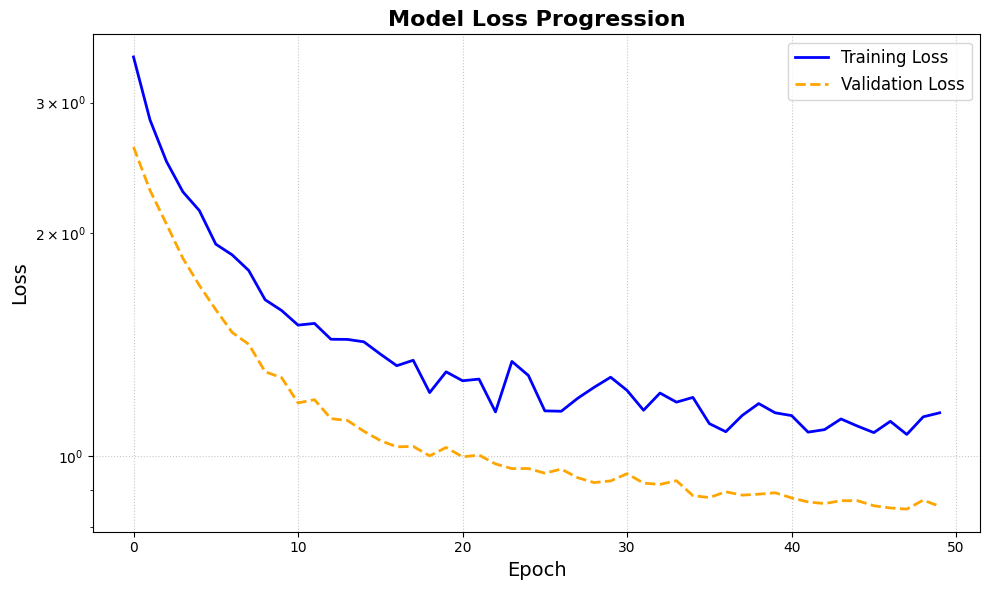

In [11]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat, log_scale=True)

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [12]:
from torchvision.transforms import v2
import random
non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x.data[random.choice(non_identity_perms), :, :]
)

rare_class_aug = [
    #forced_channel_shuffle,
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(300,200),
                         scale=(0.4,1.0))
        
    ]),
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(),
    ]),
    v2.RandomErasing(p=1)
]


fatigue_aug = v2.Compose([
    v2.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
])

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(300,200)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.8120752), np.float32(0.69213367), np.float32(0.76717395)], std=[np.float32(0.27568495), np.float32(0.35437098), np.float32(0.24276732)], inplace=False)
])

## Preparation of the model for fine-tuning

### 2. Regenerating the train/val/test split for all classes

In [13]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=rare_class_aug,
    allowed_classes=None
)

full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

In [14]:
wrapped_full_screen_train_loader = StochasticCutMixDataLoader(
    full_screen_train_loader, num_classes=20, p=0.5
)

### 6. Preparation of the parameters for fine-tuning

In [15]:
MAX_WARMUP_EPOCHS = 10
MAX_DRIFT_EPOCHS = 40

loss_fn = nn.NLLLoss()
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 5e-5, 'weight_decay': 1e-2},
    {'params': model.classifier.parameters(), 'lr': 1e-4, 'weight_decay': 1e-2}
], eps=1e-5)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [16]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=wrapped_full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2", bn_eval=True)

=== Training on the warmup_2 ===
Starting training of the warmup_2 in 10 epochs.
 warmup_2 training epoch 1/10...
Train Epoch: 1 [0/4096 (0%)]	Loss: 11.480823
Train Epoch: 1 [384/4096 (9%)]	Loss: 9.358835
Train Epoch: 1 [768/4096 (19%)]	Loss: 7.540641
Train Epoch: 1 [1152/4096 (28%)]	Loss: 6.252292
Train Epoch: 1 [1536/4096 (38%)]	Loss: 6.770720
Train Epoch: 1 [1920/4096 (47%)]	Loss: 5.602486
Train Epoch: 1 [2304/4096 (56%)]	Loss: 6.684548
Train Epoch: 1 [2688/4096 (66%)]	Loss: 5.148840
Train Epoch: 1 [3072/4096 (75%)]	Loss: 4.406282
Train Epoch: 1 [3456/4096 (84%)]	Loss: 5.155224
Train Epoch: 1 [3840/4096 (94%)]	Loss: 5.098647
--- Epoch 1 Training Metrics ---
Average Train Loss: 6.432889

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 3.917299, Accuracy: 13.70%

Total time of epoch 1 is 40.95s

 warmup_2 training epoch 2/10...
Train Epoch: 2 [0/4096 (0%)]	Loss: 3.905040
Train Epoch: 2 [384/4096 (9%)]	Loss: 4.041823
Train Epoch: 2 [768/4096 (19%)]	Loss: 4.448205
Train Epoch: 

In [17]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-3
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=wrapped_full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2", bn_eval=True)

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_2 ===
Starting training of the drift_2 in 40 epochs.
 drift_2 training epoch 1/40...
Train Epoch: 1 [0/4096 (0%)]	Loss: 2.010169
Train Epoch: 1 [384/4096 (9%)]	Loss: 2.188648
Train Epoch: 1 [768/4096 (19%)]	Loss: 2.763957
Train Epoch: 1 [1152/4096 (28%)]	Loss: 2.373799
Train Epoch: 1 [1536/4096 (38%)]	Loss: 2.153042
Train Epoch: 1 [1920/4096 (47%)]	Loss: 2.420298
Train Epoch: 1 [2304/4096 (56%)]	Loss: 2.003711
Train Epoch: 1 [2688/4096 (66%)]	Loss: 2.377498
Train Epoch: 1 [3072/4096 (75%)]	Loss: 1.365258
Train Epoch: 1 [3456/4096 (84%)]	Loss: 2.164814
Train Epoch: 1 [3840/4096 (94%)]	Loss: 2.078308
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.149929

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.324256, Accuracy: 34.82%

Total time of epoch 1 is 36.18s

 drift_2 training epoch 2/40...
Train Epoch: 2 [0/4096 (0%)]	Loss: 1.897018
Train Epoch: 2 [384/4096 (9%)]	Loss: 1.706091
Train Epoch: 2 [768/4096 (19%)]	Loss: 2.043053
Train Epoch: 2 [11

(2.533105594771249, 0.3972602739726027)

### Plotting final train/test split

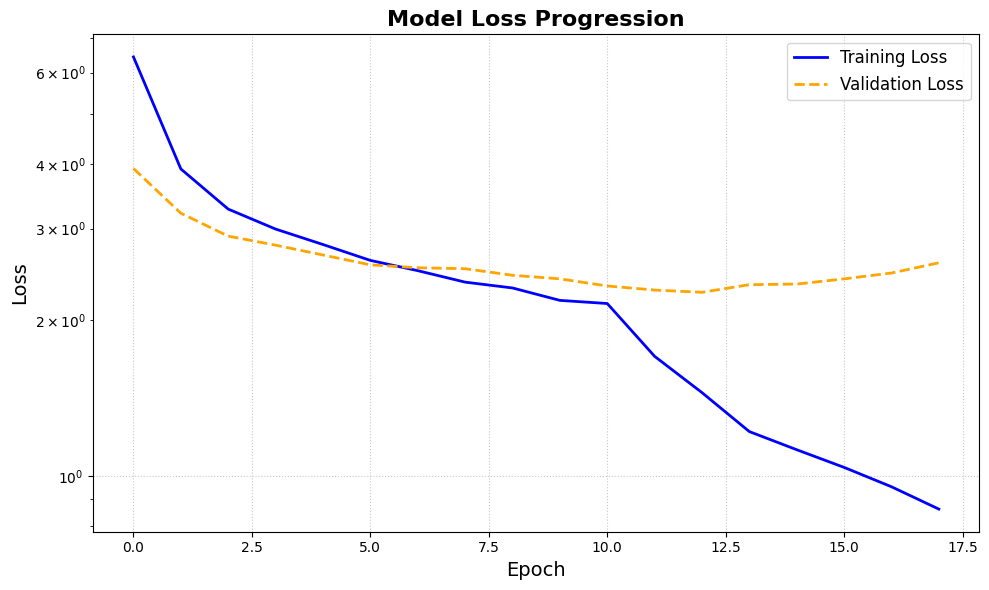

In [18]:
train_loss_list = train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list, log_scale=True)

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [19]:
import torch.optim as optim
import torch.nn as nn
MAX_SCREEN_EPOCHS = 50

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(300,200)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.8120752), np.float32(0.69213367), np.float32(0.76717395)], std=[np.float32(0.27568495), np.float32(0.35437098), np.float32(0.24276732)], inplace=False)
])


In [20]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=rare_class_aug,
    allowed_classes=None
)

full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

In [21]:
wrapped_full_screen_train_loader = StochasticCutMixDataLoader(
    full_screen_train_loader, num_classes=20, p=0.5
)

In [22]:
model = PseudoAlexNet(tiny_factor=3, p=0.25) # with dropout and with LeakyReLU

loss_fn = nn.NLLLoss()
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 5e-5, 'weight_decay': 5e-2},
    {'params': model.classifier.parameters(), 'lr': 5e-5, 'weight_decay': 5e-2}
], eps=1e-5)

val_loss_list_screen = []
train_loss_list_screen = []

model = model.to(DEVICE)
print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

=== Training on the screen ===
Starting training of the screen in 50 epochs.
 screen training epoch 1/50...
Train Epoch: 1 [0/4096 (0%)]	Loss: 5.727792
Train Epoch: 1 [384/4096 (9%)]	Loss: 4.337720
Train Epoch: 1 [768/4096 (19%)]	Loss: 4.276656
Train Epoch: 1 [1152/4096 (28%)]	Loss: 3.430391
Train Epoch: 1 [1536/4096 (38%)]	Loss: 3.691859
Train Epoch: 1 [1920/4096 (47%)]	Loss: 3.304892
Train Epoch: 1 [2304/4096 (56%)]	Loss: 3.169088
Train Epoch: 1 [2688/4096 (66%)]	Loss: 3.320921
Train Epoch: 1 [3072/4096 (75%)]	Loss: 2.699815
Train Epoch: 1 [3456/4096 (84%)]	Loss: 3.440022
Train Epoch: 1 [3840/4096 (94%)]	Loss: 2.819243
--- Epoch 1 Training Metrics ---
Average Train Loss: 3.661684

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.828984, Accuracy: 20.66%

Total time of epoch 1 is 35.55s

 screen training epoch 2/50...
Train Epoch: 2 [0/4096 (0%)]	Loss: 2.612463
Train Epoch: 2 [384/4096 (9%)]	Loss: 3.148716
Train Epoch: 2 [768/4096 (19%)]	Loss: 3.113885
Train Epoch: 2 [1152/4

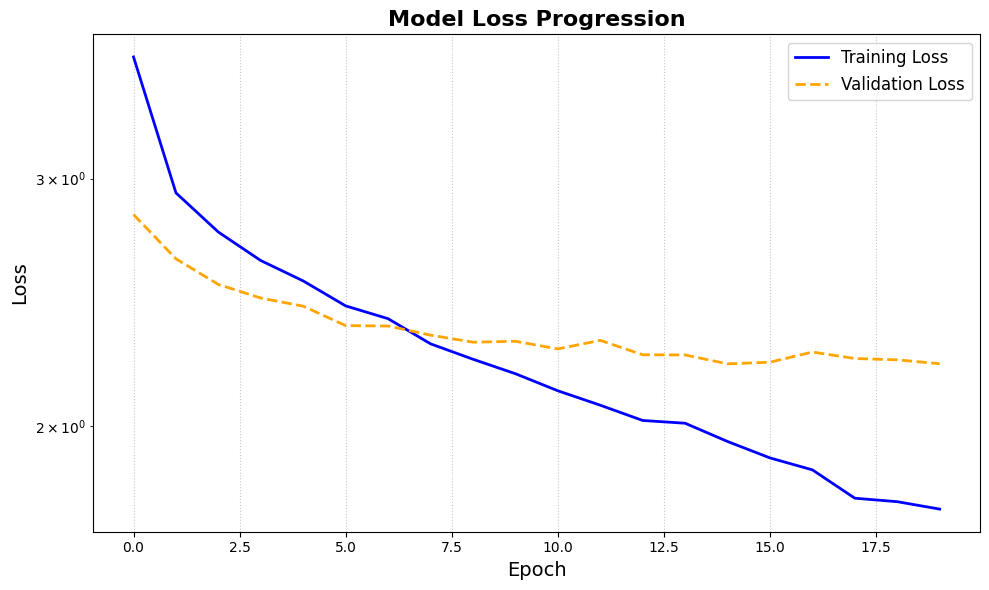

In [23]:
train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=wrapped_full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen", bn_eval=True)


evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen, log_scale=True)